# Head Over Heel
## Classifying Severe Injuries with OSHA Data

**Authors:** Emery Kerani, Amaya Supancich-McCord, Courtney St. Onge, Sadie Levin

**Date:** April 20th, 2026

---

# Project Overview
This project analyzes workplace injury data from the Occupational Safety and Health Administration (OSHA) to classify whether an incident results in hospitalization. We compare multiple machine learning models using both structured categorical features and unstructured narrative text.

---

# Objectives
In this project, we aim to: 

- Predict hospitalization outcomes using injury characteristics.
- Compare performance across Random Forest, K-Nearest Neighbors, and Support Vector Classification models.
- Evaluate how natural language narratives impact the performance of these models.

---

# Data Description
- **Source:** OSHA Severe Injury Dashboard (link: https://www.osha.gov/severe-injury-reports)
- **Observations:** 102,922, collected between January 2015 and July 2025
- **Format:** CSV

## Severe Injury Definition
OSHA defines severe injuries as incidents involving one or more of the following:
- Hospitalization
- Amputation(s)
- Loss of eye(s)

---

# Constraints and Limitations
As we explore these data, there are some important factors to keep in mind, including but not limited to:

- **Reporting Bias:** Data depends on employer-reported incidents, which may lead to biased or inaccurate reports if employers try to minimize their responsibility for incidents.
- **Federalism Effects:** Some states (e.g. CA, OR, and WA) have their own state plans or departments that govern severe injury reports and don't report directly to OSHA, meaning that the data we do have for these states is inconsistent in its coverage.
- **Data Inconsistency:** Variation in reporting practices exists across entities. Narratives may be structured differently depending on who is reporting an injury, and some categorizations may be subjective or dependent on individual interpretation. 

In [1]:
# Imports and Setup

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report

sns.set_style("whitegrid")

---

## Data Loading and Initial Exploration

We begin by loading the dataset and inspecting the structure and dimensionality of key categorical variables. Many features exhibit extremely high cardinality, which motivated dimensionality reduction through grouping these variables into more generic categories.

In [ ]:
# Load dataset
# Note: this code should be able to run as long as the csv is 
# in the same file as the notebook
df = pd.read_csv("./January2015toJuly2025.csv")

# Preview data
df.head()

C:\Users\jiake\AppData\Local\Temp\ipykernel_20108\3545065832.py:2: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("./January2015toJuly2025.csv")


,ID,UPA,EventDate,Employer,Address1,Address2,City,State,Zip,Latitude,...,NatureTitle,Part of Body,Part of Body Title,Event,EventTitle,Source,SourceTitle,Secondary Source,Secondary Source Title,FederalState
0,2015010015,931176,1/1/2015,FCI Otisville Federal Correctional Institution,Two Mile Drive,NaN,OTISVILLE,NEW YORK,10963.0,41.46,...,Fractures,513,Lower leg(s),1214,Injured by physical contact with person while ...,5721,Co-worker,5772.0,Inmate or detainee in custody,1
1,2015010016,930267,1/1/2015,Kalahari Manufacturing LLC,171 Progress Drive,NaN,LAKE DELTON,WISCONSIN,53940.0,43.59,...,Second degree heat (thermal) burns,519,"Leg(s), n.e.c.",317,"Ignition of vapors, gases, or liquids",7261,"Welding, cutting, and blow torches",NaN,NaN,1
2,2015010018,929823,1/1/2015,Schneider National Bulk Carrier,420 CORAOPOLIS ROAD,NaN,CORAOPOLIS,PENNSYLVANIA,15108.0,40.49,...,"Traumatic injuries and disorders, unspecified",9999,Nonclassifiable,4331,Other fall to lower level less than 6 feet,8421,"Semi, tractor-trailer, tanker truck",741.0,Ladders-fixed,1
3,2015010019,929711,1/1/2015,PEPSI BOTTLING GROUP INC.,4541 HOUSTON AVE.,NaN,MACON,GEORGIA,31206.0,32.77,...,"Soreness, pain, hurt-nonspecified injury",510,"Leg(s), unspecified",640,Caught in or compressed by equipment or object...,8623,Pallet jack-powered,8420.0,"Truck-motorized freight hauling and utility, u...",1
4,2015010020,929642,1/1/2015,North American Pipe Corporation,210 South Arch Street,NaN,JANESVILLE,WISCONSIN,53545.0,42.67,...,Fractures,4429,"Finger(s), fingernail(s), n.e.c.",6411,Caught in running equipment or machinery durin...,350,"Metal, woodworking, and special material machi...",NaN,NaN,1


As noted above, we see here that all of the variables we'll be working with in this section have a high number of categories, which are not always meaningfully distinct from one another (for example, many of the options for body parts refer to fingers in some way).

In [3]:
# Inspect categorical cardinality (original number of options)
print('Unique natures: ', len(df['NatureTitle'].unique()))
print('Unique parts of body: ', len(df['Part of Body Title'].unique()))
print('Unique events: ', len(df['EventTitle'].unique()))
print('Unique sources: ', len(df['SourceTitle'].unique()))
print('Unique secondary sources: ', len(df['Secondary Source Title'].unique()))


Unique natures:  345
Unique parts of body:  274
Unique events:  644
Unique sources:  1933
Unique secondary sources:  1625


## Data Cleaning and Feature Engineering

To reduce dimensionality and improve model performance, we group OSHA-coded variables into broader categories using the numerical code provided in the data. This helps:

- Reduce sparsity in one-hot encoding  
- Improve generalization  
- Preserve meaningful structure  

Each function below maps detailed OSHA codes to generalized categories.

In [4]:
def clean_body(entry):
    """
    Generalizes OSHA body part codes into broader anatomical categories.

    Parameters
    ----------
    Input: int or str
        OSHA body part code.

    Return
    -------
    str
        Generalized/root version of body part category.

    Notes
    -----
    Returns 'Nonclassifiable' for invalid or missing values.
    """

    entry = str(entry)
    if entry[0] == '1':
        return 'Head'
    elif entry[0] == '2':
        return 'Neck'
    elif entry[0] == '3':
        if entry[1] == '1':
            return 'Chest'
        elif entry[1] == '2':
            return 'Back'
        elif entry[1] == '3':
            return 'Abdomen'
        elif entry[1] == '4':
            return 'Pelvic'
        else:
            return 'Other Trunk'

    elif entry[0] == '4':
        if entry[1] == '1':
            return 'Shoulder'
        elif entry[1] == '2':
            return 'Arms'
        elif entry[1] in ['3','4']:
            if entry[1:3] == '42':
                return 'Finger'
            else:
                return 'Hand and Wrist'
        elif entry[1] == '8':
            return 'Multiple Upper Extremities'
        else:
            return 'Other Upper Extremeties'

    elif entry[0] == '5':
        if entry[1] == '1':
            return 'Leg'
        elif entry[1] in ['2','3']:
            return 'Ankle and Foot'
        elif entry[1] == '8':
            return 'Multiple Lower Extremities'
        else:
            return 'Other Lower Extremities'

    elif entry[0] == '6':
        return 'Body Systems'
    elif entry[0] == '8':
        return 'Multiple Locations'
    elif entry[0] == '9':
        return 'Prosthetic and Orthopedic'
    else:
        return 'Nonclassifiable'

In [5]:
def clean_source(entry):
    """
    Generalizes OSHA source codes into broader categories (used for primary and secondary source).

    Parameters
    ----------
    Input: int or str

    Returns
    -------
    str
        Generalized/root version source category.
    """

    entry = str(entry)
    if entry[0] == '1':
        return 'Chemicals and chemical products'
    elif entry[0] == '2':
        return 'containers, furniture, and fixtures'
    elif entry[0] == '3':
        return 'Machinery'
    elif entry[0] == '4':
        return 'Parts and materials'
    elif entry[0] == '5':
        return 'Persons, plants, animals, and minerals'
    elif entry[0] == '6':
        return 'Structures and surfaces'
    elif entry[0] == '7':
        return 'Tools, instruments, and equipment'
    elif entry[0] == '8':
        return 'Vehicles'
    elif entry[0] == '9':
        return 'Other sources'
    else:
        return 'Nonclassifiable'

In [6]:
def clean_event(entry):
    """
    Generalizes OSHA event codes into broader categories.

    Parameters
    ----------
    Input: int or str

    Returns
    -------
    str
        Generalized/root version of event category.
    """

    entry = str(entry)
    if entry[0] == '1':
        return 'Violence and other injuries by persons or animals'
    elif entry[0] == '2':
        return 'Transportation incidents'
    elif entry[0] == '3':
        return 'Fires and explosions'
    elif entry[0] == '4':
        return 'Falls, slips, trips'
    elif entry[0] == '5':
        return 'Exposure to harmful substances or environments'
    elif entry[0] == '6':
        return 'Contact with objects and equipment'
    elif entry[0] == '7':
        return 'Overexertion and bodily reaction'
    else:
        return 'Nonclassifiable'

In [7]:
def clean_nature(entry):
    """
    Generalizes OSHA injury nature codes.

    Parameters
    ----------
    Input: int or str

    Returns
    -------
    str
        Generalized/root version of injury type.
    """

    entry = str(entry)
    if entry[0] == '1':
        if entry[0:3] == '111':
            return 'Fracture'
        elif entry[0:3] == '112':
            return 'Traumatic spinal cord injury'
        elif entry[0:3] == '113':
            return 'Traumatic nerve injury'
        elif entry[0:3] == '118':
            return 'Multiple Traumatic injuries to bones, nerves, spinal cord'
        elif entry[0:2] == '11':
            return 'Other traumatic injury to bones, nerves, spinal cord'
        elif entry[0:3] == '120':
            return 'Dislocation'
        elif entry[0:3] == '122':
            return 'Cartilage fracture or tear'
        elif entry[0:3] == '123':
            return 'Sprain, strain, or tear'
        elif entry[0:3] == '128':
            return 'Multiple traumatic injuries to muscles, tendons, ligaments, joints, etc.'
        elif entry[0:2] == '12':
            return 'Other traumatic injury to muscles, tendons, ligaments, joints, etc.'
        elif entry[0:2] == '13':
            if entry[0:3] == '131':
                return 'Amputations, Avulsions, Enucleations'
            else:
                return 'Open wound'
        elif entry[0:2] == '14':
            return 'Surface wounds and bruises'
        elif entry[0:2] == '15':
            return 'Burns and corrosions'
        elif entry[0:2] == '16':
            return 'Intracranial injuries'
        elif entry[0:2] == '17':
            return 'Environmental condition'
        elif entry[0:3] == '18':
            return 'Multiple traumatic injuries'
        elif entry == '1971':
            return 'Crushing injury'
        else:
            return 'Other traumatic injury'

    elif entry[0] == '2':
        return 'Disease or disorder of body system(s)'

    elif entry[0] == '3':
        return 'Infectious or parasitic disease(S)'

    elif entry[0] == '4':
        return 'Neoplasms, tumors, and cancer'

    elif entry[0] == '5':
        return 'Symptoms, signs, and ill-defined conditions'

    elif entry[0] == '6':
        return 'Other diseases, conditions, and disorders'

    elif entry[0] == '7':
        return 'Exposure to disease - no illness incurred'

    elif entry[0] == '8':
        return 'Multiple diseases, conditions, and disorders'

    else:
        return 'Nonclassifiable'

We can now apply these functions to their corresponding columns. Note that the `clean_source` function can be used for both the *Source* and *Secondary Source* columns, as both columns use the same codes.

In [8]:
# Applying transformations to original columns
df['Source Cleaned'] = df['Source'].apply(lambda x: clean_source(x))
df['Event Cleaned'] = df['Event'].apply(lambda x: clean_event(x))
df['Body Cleaned'] = df['Part of Body'].apply(lambda x: clean_body(x))
df['Nature Cleaned'] = df['Nature'].apply(lambda x: clean_nature(x))
df['Secondary Source Cleaned'] = df['Secondary Source'].apply(lambda x: clean_source(x))


## Graphing Distributions

With the generalized columns, we are now able to explore the data and visualize the most common drivers of severe injury. In each graph, the original number of categories is noted in the lower-right corner.

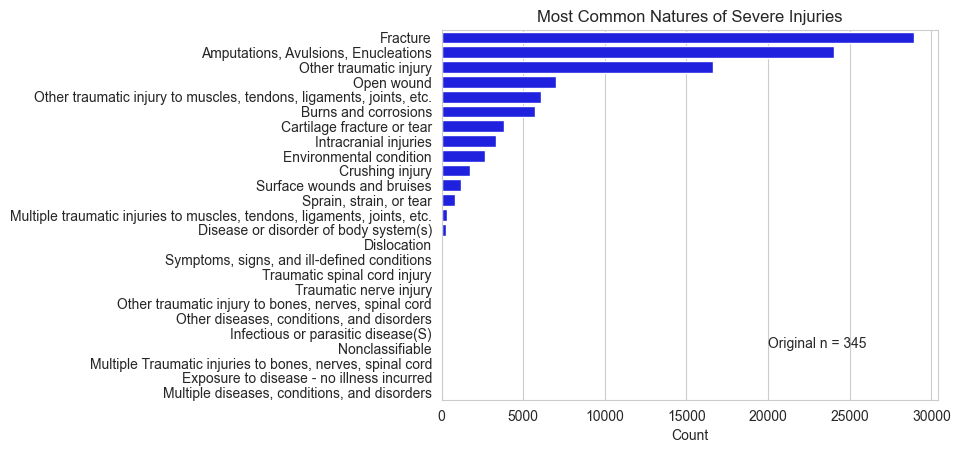

In [9]:
# Graphing nature distribution
sns.countplot(data=df, y='Nature Cleaned', order=df['Nature Cleaned'].value_counts().index, color='blue')
plt.xlabel('Count')
plt.ylabel('')
plt.title('Most Common Natures of Severe Injuries')
plt.text(x=20000, y=21, s='Original n = 345')
plt.show()

Our most common recorded natures of severe injury are fractures, amputations, avulsions (when a fragment of bone, tendon, or ligament is forcibly torn away from the main bone), enucleations (surgical removal of the entire eyeball, leaving eye muscles and orbital contents intact), and traumatic injury, all accounting for well over 15000 cases. Unsurprisingly, injuries like traumatic spinal cord injuries account for a much smaller proportion of injuries, likely because the spinal region is such a fragile system; most injuries related to this region result in death, and therefore, are not reported in our severe injury database.

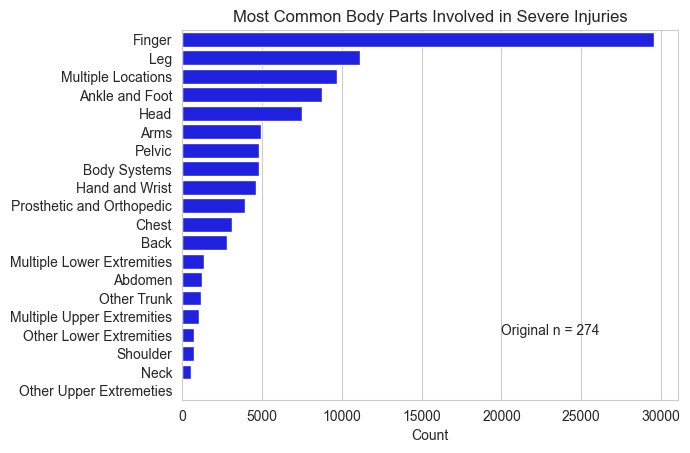

In [10]:
# Graphing body part distribution
sns.countplot(data=df, y='Body Cleaned', order=df['Body Cleaned'].value_counts().index, color='blue')
plt.xlabel('Count')
plt.ylabel('')
plt.title('Most Common Body Parts Involved in Severe Injuries')
plt.text(x=20000, y=16, s='Original n = 274')
plt.show()

Our most commonly reported body part involved in severe injury is the finger (nearly 30,000 cases); this is unsurprising given the nature of most OSHA-inspected work and surface-level data inspections. On OSHA's own severe injury dashboard, the top five body parts include "fingertip(s)" (30%), "finger(s), fingernail(s), n.e.c." (24%), and "finger(s), fingernail(s), unspecified" (20%); 74% of the top five body parts to be involved in a severe injury involve the finger in some capacity. Similar to the discussion of traumatic spinal cord injuries, injuries to the neck are also likely to be reported in low numbers due to injuries in this region often resulting in death rather than hospitalization.

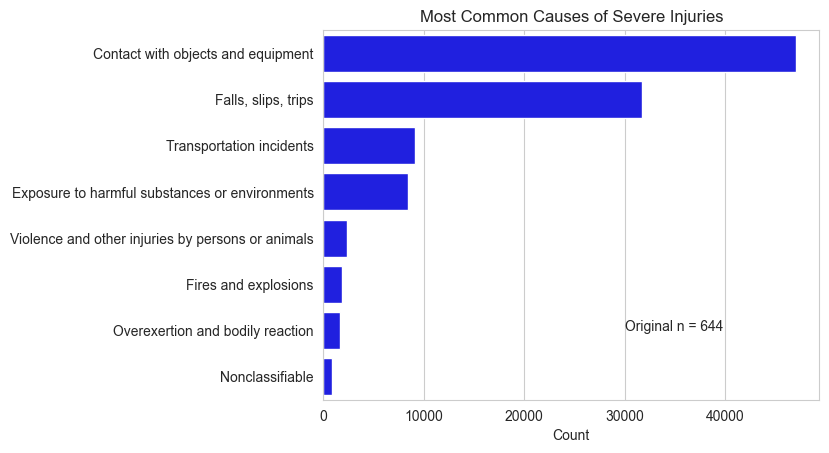

In [11]:
# Graphing event distribution
sns.countplot(data=df, y='Event Cleaned', order=df['Event Cleaned'].value_counts().index, color='blue')
plt.xlabel('Count')
plt.ylabel('')
plt.title('Most Common Causes of Severe Injuries')
plt.text(x=30000, y=6, s='Original n = 644')
plt.show()

Our most common causes of severe injuries are "contact with objects and equipment" at roughly 40,750 cases, and "falls, slips, trips" at roughly 30,000. Coming in at a close tie are "transportation incidents" and "exposure to harmful substances or environments," both slightly under 10,000. Unsurprisingly, injury causes that are less prevalent in common workplaces, like violence and other injuries by animals and explosions, are reported at under 5,000 cases. 

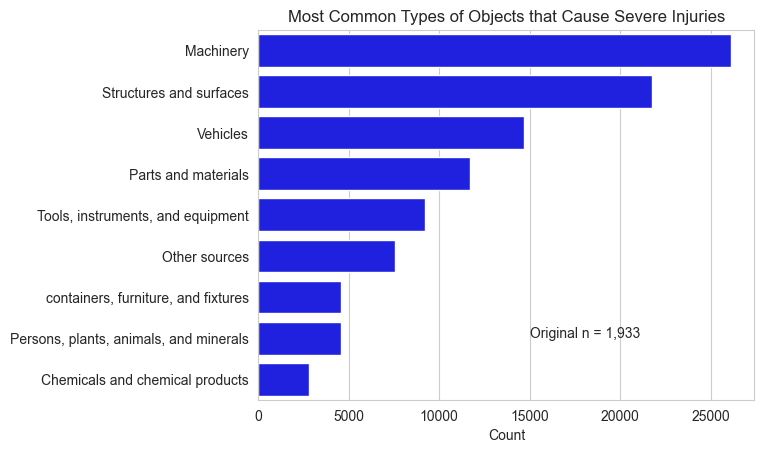

In [12]:
# Graphing source distribution
sns.countplot(data=df, y='Source Cleaned', order=df['Source Cleaned'].value_counts().index, color='blue')
plt.xlabel('Count')
plt.ylabel('')
plt.title('Most Common Types of Objects that Cause Severe Injuries')
plt.text(x=15000, y=7, s='Original n = 1,933')
plt.show()

Our most common types of objects that cause severe injuries include machinery (over 25,000) and structures and surfaces (over 20,000). As in the discussion of injury causes, objects that workers are less likely to encounter in everyday work activities (for example, chemicals and chemical products) are unsurprisingly responsible for fewer severe injuries (fewer than 5,000).

## Filtering and Feature Selection

The next step in cleaning is to restrict the dataset to valid binary outcomes, which removes ambiguity. We also select the variables that we will use for modeling, which in this case only includes hospitalization as an outcome; future work could attempt to classify amputations, loss of eyes, or somehow combine the outcome variables.

In [13]:
# Filter valid binary outcomes (make hospitalized a boolean)
df = df.loc[np.where((df['Hospitalized'] <= 1) & (df['Amputation'] <= 1))]

# Select relevant columns
df = df[['State','Hospitalized','Amputation','Loss of Eye','Final Narrative','Nature','Nature Cleaned','Part of Body','Body Cleaned','Event','Event Cleaned','Source','Source Cleaned',
         'Secondary Source','Secondary Source Cleaned']]

---

## Writing-out and Reading-in Cleaned Data

We write the cleaned version of the dataset to a CSV file to save and export (and use again in later sections), and then read it back in.

In [14]:
# Writing-out cleaned version
df.to_csv('machine-learning-data-cleaned.csv')

# Reading-in cleaned version
df = pd.read_csv('machine-learning-data-cleaned.csv')

## Preparing Data for Modeling

Here we separate the features and labels, then apply one-hot encoding to categorical variables. This turns each category into its own binary column, which makes it easier for most models to work with. Once the variables are encoded, we can split them into a training and testing set.

In [15]:
# Separating labels
df_labels = df['Hospitalized']

# Drop unused columns
df.drop(['State','Hospitalized','Amputation','Loss of Eye','Final Narrative','Unnamed: 0','Nature', 'Part of Body',
         'Event', 'Source', 'Secondary Source'], axis=1, inplace=True)

# One-hot encoding
df = pd.get_dummies(df)

In [ ]:
# Train test split (stratified by hospitalized, as there are significantly fewer cases of non-hospitalization)
X_train, X_test, y_train, y_test = train_test_split(df, df_labels, test_size=0.25, train_size=0.75, random_state = 42, stratify=df_labels)

---

## Modeling Approach

In this project we aim to evaluate three models:

- Random Forest: handles nonlinear relationships and feature interactions.  
- KNN: distance-based method sensitive to feature scaling.  
- SVC: effective in high-dimensional feature spaces.  

### Evaluation Metrics

To evalute performance we focus on three key metrics:

- Precision (minimize false positives)  
- Recall (capture true hospitalizations)  
- F1-score (balance of precision and recall)

F-1 score is more helpful than accuracy in this case, because there is a large difference in the number of hospitalizations and non-hospitalizations present in our data.

---

## Random Forest

Our first model is a random forest. In our review of published research similar to this project, random forest models generally seemed to be the highest-performing, so we wanted to see if those results would hold.

In [69]:
# Initializing Random Forest
forest = RandomForestClassifier(random_state=42)
forest.fit(X_train, y_train)

print('Random forest score:',forest.score(X_test, y_test))

# Getting predictions based on the test set
y_pred_forest = forest.predict(X_test)

# Classification report
print('\nClassification report:')
print(classification_report(y_test, y_pred_forest))

# Calculating the precision, accuracy, and F1 scores based on confusion matrix
cm_forest = confusion_matrix(y_test, y_pred_forest)
precision = cm_forest[1][1] / (cm_forest[1][1] + cm_forest[0][1])
recall = cm_forest[1][1] / (cm_forest[1][1] + cm_forest[1][0])
f1 = 2 * ((precision * recall) / (precision + recall))

print('Confusion matrix:\n', cm_forest)
print('Precision: ', precision)
print('Recall:', recall)
print('F1:', f1)

Random forest score: 0.9256912667683523

Classification report:
              precision    recall  f1-score   support

         0.0       0.73      0.96      0.83      4888
         1.0       0.99      0.92      0.95     20681

    accuracy                           0.93     25569
   macro avg       0.86      0.94      0.89     25569
weighted avg       0.94      0.93      0.93     25569

Confusion matrix:
 [[ 4696   192]
 [ 1708 18973]]
Precision:  0.989981737542395
Recall: 0.9174121174024467
F1: 0.9523164182101089


**Results:**
In the non-tuned version of this model, precision (99%), accuracy (92.6%), and recall (91.7%) are all high, leading to an F1 score of 0.952.

### Tuning Random Forest

Though the threshold for improvement is relatively low in this case, we still wanted to see if we could make an even better-performing model. For the sake of saving time, we chose to use a randomized search to evaluate which combination of hyperparameters (out of `n_estimators`, `max_features`, `max_depth`, `min_samples_split`, and `min_samples_leaf`) would perform the best. 

In [18]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

# Defining tuning parameters
param_grid = {
    'n_estimators': [100, 150, 200],
    'max_features': [None, 'sqrt', 'log2'],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Finding best parameters using random search
random_search = RandomizedSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, random_state=42, n_iter=10)
random_search.fit(X_train, y_train)

print("Best Estimator:", random_search.best_estimator_)

Best Estimator: RandomForestClassifier(max_depth=10, max_features='log2', min_samples_leaf=2,
                       n_estimators=150, random_state=42)


In [68]:
# Evaluating tuned forest
bestforest = RandomForestClassifier(max_depth=10, max_features='log2', min_samples_leaf=2,
                       n_estimators=150, random_state=42)

bestforest.fit(X_train, y_train)

print('Second random forest score:',bestforest.score(X_test, y_test))

# Getting predictions based on the test set
y_pred_bf = bestforest.predict(X_test)

# Classification report
print('\nClassification report:')
print(classification_report(y_test, y_pred_bf))

# Calculating the precision, accuracy, and F1 scores based on confusion matrix
cm_bf = confusion_matrix(y_test, y_pred_bf)
precision = cm_bf[1][1] / (cm_bf[1][1] + cm_bf[0][1])
recall = cm_bf[1][1] / (cm_bf[1][1] + cm_bf[1][0])
f1 = 2 * ((precision * recall) / (precision + recall))

print('Confusion matrix:\n', cm_bf)
print('Precision: ', precision)
print('Recall:', recall)
print('F1:', f1)

Second random forest score: 0.926121475223904

Classification report:
              precision    recall  f1-score   support

         0.0       0.74      0.96      0.83      4888
         1.0       0.99      0.92      0.95     20681

    accuracy                           0.93     25569
   macro avg       0.86      0.94      0.89     25569
weighted avg       0.94      0.93      0.93     25569

Confusion matrix:
 [[ 4681   207]
 [ 1682 18999]]
Precision:  0.9892221180880975
Recall: 0.9186693099946811
F1: 0.952641211422268


**Results:**
Using the hyperparameter combination identified by our search, this model has no significant improvement. The accuracy (92.6%) and F1 (0.953) scores are both relatively similar, but interestingly the tuned version had an ever so slightly lower precision (98.9%) and a slightly higher recall (91.9%).

### Interpretation

Our Random Forest model achieves high marks across all metrics, though its recall was generally worse than its precision. This indicates effective identification of true hospitalizations while minimizing false positives, which is crucial when false positives are costly. The tuned version of the random forest does not outperform the untuned version to a significant degree.

--- 

## SVC

We wanted to test a Support Vector Classification model for precisely the opposite reason we used a Random Forest: SVC was not as widely mentioned in the articles we previously looked at, which made us curious how it would perform in comparison to more widely-used models.

In [67]:
# Initializing SVC
svc = SVC(random_state=42)

svc.fit(X_train, y_train)

print('SVC score:', svc.score(X_test, y_test))

# Getting predictions based on the test set
y_pred_svc = svc.predict(X_test)

# Classification report
print('\nClassification report:')
print(classification_report(y_test, y_pred_svc))

# Calculating the precision, accuracy, and F1 scores based on confusion matrix
cm_svc = confusion_matrix(y_test, y_pred_svc)
precision = cm_svc[1][1] / (cm_svc[1][1] + cm_svc[0][1])
recall = cm_svc[1][1] / (cm_svc[1][1] + cm_svc[1][0])
f1 = 2 * ((precision * recall) / (precision + recall))

print('Confusion matrix:\n', cm_svc)
print('Precision: ', precision)
print('Recall:', recall)
print('F1:', f1)

SVC score: 0.9265516836794556

Classification report:
              precision    recall  f1-score   support

         0.0       0.74      0.96      0.83      4888
         1.0       0.99      0.92      0.95     20681

    accuracy                           0.93     25569
   macro avg       0.86      0.94      0.89     25569
weighted avg       0.94      0.93      0.93     25569

Confusion matrix:
 [[ 4701   187]
 [ 1691 18990]]
Precision:  0.9902487354643583
Recall: 0.918234127943523
F1: 0.9528827337046514


**Results:**
This model also performed highly across all metrics. Even without tuning, it performs slightly better than the tuned Random Forest model, with a similar recall (91.8%) and slightly higher precision (99%), accuracy (92.7%), and F1 (0.953) scores.

### Tuning SVC

Again, however, we wanted to see if the model could be improved at all. We used another randomized grid search, focusing on the most impactful hyperparameters (`C` and `gamma`), as another time-saving measure. 

In [21]:
# Defining SVC parameters
param_grid = {'C': [0.1, 1, 10, 100, 1000],
			'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
			'kernel': ['rbf']}

# Finding best parameters using random grid searching
grid = RandomizedSearchCV(SVC(random_state = 42), param_grid, refit=True)
grid.fit(X_train, y_train)
print('Best estimator: ', grid.best_estimator_)

Best estimator:  SVC(C=1, gamma=0.1, random_state=42)


In [66]:
# Evaluating tuned SVC
better_svc = SVC(C=1, gamma=0.1, random_state=42)

better_svc.fit(X_train, y_train)

print('Tuned SVC score:', better_svc.score(X_test, y_test))

# Getting predictions based on the test set
y_pred_svc_b = better_svc.predict(X_test)

# Classification report
print('\nClassification report:')
print(classification_report(y_test, y_pred_svc_b))

# Calculating the precision, accuracy, and F1 scores based on confusion matrix
cm_svc_b = confusion_matrix(y_test, y_pred_svc_b)
precision = cm_svc_b[1][1] / (cm_svc_b[1][1] + cm_svc_b[0][1])
recall = cm_svc_b[1][1] / (cm_svc_b[1][1] + cm_svc_b[1][0])
f1 = 2 * ((precision * recall) / (precision + recall))

print('Confusion matrix:\n', cm_svc_b)
print('Precision: ', precision)
print('Recall:', recall)
print('F1:', f1)

Tuned SVC score: 0.9264734639602644

Classification report:
              precision    recall  f1-score   support

         0.0       0.74      0.96      0.83      4888
         1.0       0.99      0.92      0.95     20681

    accuracy                           0.93     25569
   macro avg       0.86      0.94      0.89     25569
weighted avg       0.94      0.93      0.93     25569

Confusion matrix:
 [[ 4702   186]
 [ 1694 18987]]
Precision:  0.9902988577687373
Recall: 0.9180890672598037
F1: 0.9528278215486525


**Results:**
Interestingly, this version of our SVC actually performed ever so slightly worse than the initial version, with a higher accuracy and precision but lower recall and F1 score. These differences are so marginal, however, that in practice they only amount to 4 differently-classified cases.

### Interpretation

Our SVC provides the best overall balance (highest F1-score), making it the preferred model for this classification task. The tuned version of the SVC performs slightly worse than the untuned version, but both versions performed better than the Random Forest.

--- 

## KNN

The final model we evaluate is a K-Nearest Neighbors model. This is among the most common algorithms and is usually more interpretable, so we wanted to see how it would stack up against the success we had already had with our Random Forest and SVC models.

In [65]:
from sklearn.neighbors import KNeighborsClassifier

# Initializing KNN
knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

print('KNN score:', knn.score(X_test, y_test))

# Getting predictions based on the test set
y_pred_knn = knn.predict(X_test)

# Classification report
print('\nClassification report:')
print(classification_report(y_test, y_pred_knn))

# Calculating the precision, accuracy, and F1 scores based on confusion matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)
precision = cm_knn[1][1] / (cm_knn[1][1] + cm_knn[0][1])
recall = cm_knn[1][1] / (cm_knn[1][1] + cm_knn[1][0])
f1 = 2 * ((precision * recall) / (precision + recall))

print('Confusion matrix:\n', cm_knn)
print('Precision: ', precision)
print('Recall:', recall)
print('F1:', f1)

KNN score: 0.9190817004966952

Classification report:
              precision    recall  f1-score   support

         0.0       0.73      0.93      0.81      4888
         1.0       0.98      0.92      0.95     20681

    accuracy                           0.92     25569
   macro avg       0.85      0.92      0.88     25569
weighted avg       0.93      0.92      0.92     25569

Confusion matrix:
 [[ 4531   357]
 [ 1712 18969]]
Precision:  0.9815274759391494
Recall: 0.9172187031574875
F1: 0.948284050291199


**Results:**

Though its scores are high and would be acceptable as a standalone model, our KNN does slightly underperform relative to our first models. It returns the lowest scores we've seen so far, across the board - but those scores are still all above the 0.90 mark. 

### Tuning KNN

With KNN models, it's important that we find the optimal number of neighbors. To do so, we used cross-folding to get the average model performance across a range of 1 to 21 neighbors; from this we can identify the number of neighbors that on average returned the most accuracy (13).

In [24]:
k_range = range(1, 21)
cv_scores = []

# Evaluate each k using 5-fold cross-validation
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

In [25]:
# Finding the number of neighbors with highest score
print('Max score: ', max(cv_scores))
print('Best K: ', k_range.index(cv_scores.index(max(cv_scores))))

Max score:  0.9215195644768288
Best K:  13


In [64]:
# Evaluating tuned KNN
better_knn = KNeighborsClassifier(n_neighbors = 13)

better_knn.fit(X_train, y_train)

print('KNN (13 neighbors) score:', better_knn.score(X_test, y_test))

# Getting predictions based on the test set
y_pred_knn_b = better_knn.predict(X_test)

# Classification report
print('\nClassification report:')
print(classification_report(y_test, y_pred_knn_b))

# Calculating the precision, accuracy, and F1 scores based on confusion matrix
cm_knn_b = confusion_matrix(y_test, y_pred_knn_b)
precision = cm_knn_b[1][1] / (cm_knn_b[1][1] + cm_knn_b[0][1])
recall = cm_knn_b[1][1] / (cm_knn_b[1][1] + cm_knn_b[1][0])
f1 = 2 * ((precision * recall) / (precision + recall))

print('Confusion matrix:\n', cm_knn_b)
print('Precision: ', precision)
print('Recall:', recall)
print('F1:', f1)

KNN (13 neighbors) score: 0.9238922132269545

Classification report:
              precision    recall  f1-score   support

         0.0       0.73      0.96      0.83      4888
         1.0       0.99      0.91      0.95     20681

    accuracy                           0.92     25569
   macro avg       0.86      0.94      0.89     25569
weighted avg       0.94      0.92      0.93     25569

Confusion matrix:
 [[ 4706   182]
 [ 1764 18917]]
Precision:  0.9904707052725273
Recall: 0.9147043179730188
F1: 0.9510809451985923


**Results:**
The KNN's measures were improved across the board by tuning. Using an optimized number of neighbors, it is now much more comparable with both the SVC and Random Forest, though still a tiny bit worse on all measures.

### Interpretation

We found that our KNN performs slightly worse than the other models due to sensitivity to high-dimensional feature space, though its performance was boosted much more significantly by tuning than our other models. For use on categorical variables we would recommend an SVC, but any of the models we tested would still work well.

---

# Classification using narratives

## Natural Language Processing (NLP)

In this section we aim to evaluate how classification using narrative text compares to traditional category-based classification models.

### Key Pre-Processing Steps:
The following code chunks show everything we had to do in order to prepare the narratives for use with our models. This included:
- Removing punctuation  
- Tokenizing text  
- Removing stopwords  
- Lemmatizing tokens  
- Removing "hospital" from tokens to prevent label leakage  
- Applying TF-IDF vectorization

In [28]:
# Importing nltk materials
import nltk

# Dowloading necessary packages from nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\jiake\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jiake\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\jiake\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\jiake\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [29]:
# Reading in the dataset for text
text_df = pd.read_csv('machine-learning-data-cleaned.csv')

# Pulling labels
text_df_labels = text_df['Hospitalized']

# Isolating the final narrative
text_df = text_df[['Final Narrative']]

# Preview data
text_df.head()

,Final Narrative
0,Three correctional facility guards were escort...
1,Employee in the Machine Shop received second d...
2,A truck driver fell approximately 4 feet while...
3,An employee's leg was pinned between a truck a...
4,An employee working on the Line 6 Auto-Beller ...


### Pre-processing

In [30]:
# Removing punctuation
text_df['Final Narrative'] = text_df['Final Narrative'].apply(lambda x: ''.join(char for char in x if char not in string.punctuation))

In [31]:
# Ensuring column is a str
text_df['Final Narrative'] = text_df['Final Narrative'].astype(str)

# Tokenizing column
text_df['words'] = text_df.apply(lambda x: word_tokenize(x['Final Narrative']), axis=1)

# Removing stopwords
stop_words = set(stopwords.words('english'))
text_df['words'] = text_df['words'].apply(lambda x: [word for word in x if word.lower() not in stop_words])

In [32]:
# Initializing lemmatizer
lemmatizer = WordNetLemmatizer()

# Lemmatizing tokens
text_df['words_lemmatized'] = text_df['words'].apply(lambda x: [lemmatizer.lemmatize(word, pos='v') for word in x])

In [33]:
# Remove leakage word (filtering out 'hospital' from lemmatized words)
text_df['words_not_hosp'] = text_df['words_lemmatized'].apply(lambda x: [word for word in x if word.lower() != 'hospital'])

# Checking the filter worked
print(text_df['words_lemmatized'].iloc[0])
print(text_df['words_not_hosp'].iloc[0])

['Three', 'correctional', 'facility', 'guard', 'escort', 'restrain', 'federal', 'prison', 'inmate', 'become', 'disruptive', 'require', 'use', 'force', 'Two', 'guard', 'inmate', 'fell', 'onto', 'Lieutenants', 'right', 'leg', 'fracture', 'fibula', 'transport', 'hospital', 'release', 'follow', 'day']
['Three', 'correctional', 'facility', 'guard', 'escort', 'restrain', 'federal', 'prison', 'inmate', 'become', 'disruptive', 'require', 'use', 'force', 'Two', 'guard', 'inmate', 'fell', 'onto', 'Lieutenants', 'right', 'leg', 'fracture', 'fibula', 'transport', 'release', 'follow', 'day']


In [34]:
# Join tokens (allows them to be vectorized later)
text_df['tokens_together'] = text_df['words_not_hosp'].apply(lambda x: ' '.join(x))

# Getting new train test split
t_X_train, t_X_test, t_y_train, t_y_test = train_test_split(text_df['tokens_together'], text_df_labels, test_size = 0.25, random_state = 42, stratify = text_df_labels)

### Vectorizing

When performing vectorization of the cleaned text, we chose to use TF-IDF vectorization as opposed to traditional count vectorization because TF-IDF vectorization computes the relative importance of words in comparison to their surroundings, which is much more useful for our purposes than a simple count.

In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

# Vectorizing text (counts of how common each word is in relation to the other words)
x_train_count = tfidf.fit_transform(t_X_train)
x_test_count = tfidf.transform(t_X_test)

With all the pre-processing done, we can now test the same three models against this new version of the data. For the sake of time and because we saw such marginal improvements in the performance of our other models, we chose to forego tuning for the relatively more complicated Random Forest and SVC models.

---

## Text-Based Random Forest

In [62]:
# Evaluating text-based random forest
text_forest = RandomForestClassifier(random_state=42)

text_forest.fit(x_train_count, t_y_train)

print('Random forest w/ text score:', text_forest.score(x_test_count, t_y_test))

# Getting predictions based on the test set
y_pred_rf_t = text_forest.predict(x_test_count)

# Classification report
print('\nClassification report:')
print(classification_report(t_y_test, y_pred_rf_t))

# Calculating the precision, accuracy, and F1 scores based on confusion matrix
cm_rf_t = confusion_matrix(t_y_test, y_pred_rf_t)
precision = cm_rf_t[1][1] / (cm_rf_t[1][1] + cm_rf_t[0][1])
recall = cm_rf_t[1][1] / (cm_rf_t[1][1] + cm_rf_t[1][0])
f1 = 2 * ((precision * recall) / (precision + recall))

print('Confusion matrix:\n', cm_rf_t)
print('Precision: ', precision)
print('Recall:', recall)
print('F1:', f1)

Random forest w/ text score: 0.9211936329148578

Classification report:
              precision    recall  f1-score   support

         0.0       0.76      0.87      0.81      4888
         1.0       0.97      0.93      0.95     20681

    accuracy                           0.92     25569
   macro avg       0.86      0.90      0.88     25569
weighted avg       0.93      0.92      0.92     25569

Confusion matrix:
 [[ 4251   637]
 [ 1378 19303]]
Precision:  0.9680541624874623
Recall: 0.9333687926115758
F1: 0.950395115826789


**Results:**
As we might have guessed, the Random Forest using text performs slightly worse than the categorical version, but not by as much as we might have guessed! All the measures (precision = 96.8%, accuracy = 92.1%, recall = 93.3%, F1 = 0.950) are still quite high, and in fact this version's recall outperforms the original.

---

## Text-Based KNN

In [63]:
# Evaluating text-based KNN
text_knn = KNeighborsClassifier()

text_knn.fit(x_train_count, t_y_train)

print('KNN with text score:', text_knn.score(x_test_count, t_y_test))

# Getting predictions based on the test set
y_pred_knn_t = text_knn.predict(x_test_count)

# Classification report
print('\nClassification report:')
print(classification_report(t_y_test, y_pred_knn_t))

# Calculating the precision, accuracy, and F1 scores based on confusion matrix
cm_knn_t = confusion_matrix(t_y_test, y_pred_knn_t)
precision = cm_knn_t[1][1] / (cm_knn_t[1][1] + cm_knn_t[0][1])
recall = cm_knn_t[1][1] / (cm_knn_t[1][1] + cm_knn_t[1][0])
f1 = 2 * ((precision * recall) / (precision + recall))

print('Confusion matrix:\n', cm_knn_t)
print('Precision: ', precision)
print('Recall:', recall)
print('F1:', f1)

KNN with text score: 0.8490359419609683

Classification report:
              precision    recall  f1-score   support

         0.0       0.61      0.60      0.60      4888
         1.0       0.91      0.91      0.91     20681

    accuracy                           0.85     25569
   macro avg       0.76      0.75      0.75     25569
weighted avg       0.85      0.85      0.85     25569

Confusion matrix:
 [[ 2931  1957]
 [ 1903 18778]]
Precision:  0.9056185194116229
Recall: 0.9079831729606885
F1: 0.9067993046165733


**Results:**

This initial version of our KNN performs the worst yet. The precision and accuracy particularly suffer, at just 90.6% and 84.9% respectively. Recall is still relatively close to the original (90.8%), but overall the F1 drops to 0.907.

### Tuning

Because we saw such an improvement in the last KNN version after tuning, we again wanted to ensure we use the optimized number of neighbors (18). However, this time we forego the cross-fold validation in favor of using just one accuracy score per number of neighbors, as using the cross-fold with text would likely take a long time.

In [ ]:
# Finding the best number of neighbors
k_range = range(1,21)
scores = []

for k in k_range:
    # for each k making a model and getting the score
    knn = KNeighborsClassifier(n_neighbors = k)
    knn.fit(x_train_count, t_y_train)

    scores.append(knn.score(x_test_count, t_y_test))

print('Max score: ', max(scores))
print('Best K: ', k_range.index(scores.index(max(scores))))

Max score:  0.8685908717587704
Best K:  18


In [70]:
# Evaluating the text-based KNN
text_knn_better = KNeighborsClassifier(n_neighbors=18)

text_knn_better.fit(x_train_count, t_y_train)

print('Improved KNN with text score:', text_knn_better.score(x_test_count, t_y_test))

# Getting predictions based on the test set
y_pred_knn_tb = text_knn_better.predict(x_test_count)

# Classification report
print('\nClassification report:')
print(classification_report(t_y_test, y_pred_knn_tb))

# Calculating the precision, accuracy, and F1 scores based on confusion matrix
cm_knn_tb = confusion_matrix(t_y_test, y_pred_knn_tb)
precision = cm_knn_tb[1][1] / (cm_knn_tb[1][1] + cm_knn_tb[0][1])
recall = cm_knn_tb[1][1] / (cm_knn_tb[1][1] + cm_knn_tb[1][0])
f1 = 2 * ((precision * recall) / (precision + recall))

print('Confusion matrix:\n', cm_knn_tb)
print('Precision: ', precision)
print('Recall:', recall)
print('F1:', f1)

Improved KNN with text score: 0.8659705111658649

Classification report:
              precision    recall  f1-score   support

         0.0       0.64      0.67      0.66      4888
         1.0       0.92      0.91      0.92     20681

    accuracy                           0.87     25569
   macro avg       0.78      0.79      0.79     25569
weighted avg       0.87      0.87      0.87     25569

Confusion matrix:
 [[ 3289  1599]
 [ 1828 18853]]
Precision:  0.9218169372188539
Recall: 0.9116096900536724
F1: 0.9166849002017844


**Results:**

We again see a jump in performance after tuning, but not quite as pronounced as with the original model. Using 18 neighbors the precision comes in at 92.2%, accuracy at 86.6%, and recall at 91.1%, for an F1 of 0.917. Similarly to the original KNN, these measures are relatively good on their own, but the model is outperformed by the others.

---

## Text-Based SVC

In [71]:
# Evaluating text-based SVC
svc_text = SVC(random_state=42)

svc_text.fit(x_train_count, t_y_train)

print('SVC with text score:', svc_text.score(x_test_count, t_y_test))

# Getting predictions based on the test set
y_pred_svc_t = svc_text.predict(x_test_count)

# Classification report
print('\nClassification report:')
print(classification_report(t_y_test, y_pred_svc_t))

# Calculating the precision, accuracy, and F1 scores based on confusion matrix
cm_svc_t = confusion_matrix(t_y_test, y_pred_svc_t)
precision = cm_svc_t[1][1] / (cm_svc_t[1][1] + cm_svc_t[0][1])
recall = cm_svc_t[1][1] / (cm_svc_t[1][1] + cm_svc_t[1][0])
f1 = 2 * ((precision * recall) / (precision + recall))

print('Confusion matrix:\n', cm_svc_t)
print('Precision: ', precision)
print('Recall:', recall)
print('F1:', f1)

SVC with text score: 0.9264343541006688

Classification report:
              precision    recall  f1-score   support

         0.0       0.75      0.92      0.83      4888
         1.0       0.98      0.93      0.95     20681

    accuracy                           0.93     25569
   macro avg       0.87      0.92      0.89     25569
weighted avg       0.94      0.93      0.93     25569

Confusion matrix:
 [[ 4491   397]
 [ 1484 19197]]
Precision:  0.9797386955190365
Recall: 0.9282433151201586
F1: 0.9532960893854748


**Results:**
Once again, the SVC performed the best among the models using text input. Its accuracy (92.6%), precision (98%), and F1 score (0.953) are all the highest out of the text-based models, though the Random Forest performed slightly better in terms of recall.

---

## Final Comparisons

Now that we've experimented with two different versions of our three models, we can evaluate their relative performances using F1 score as our primary metric.

The final ranking is:
- SVC (text)
- SVC (categorical)
- Random forest (categorical)
- KNN (categorical)
- Random forest (text)
- KNN (text)

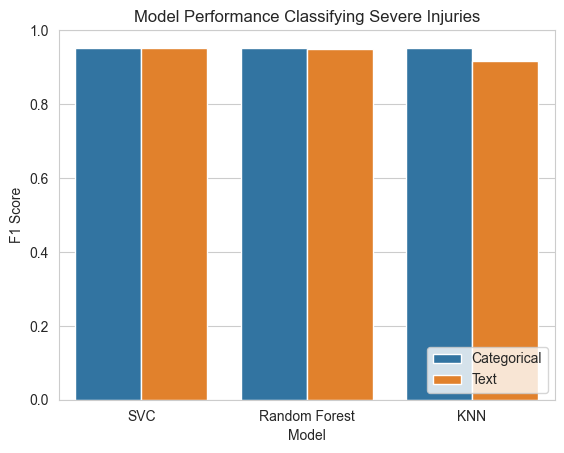

In [72]:
# Graphing the model comparisons

#Making a new df with the F1 scores of each model
final_scores = {'Model':['SVC','Random Forest','KNN','SVC','Random Forest','KNN'],
                'F1 Score':[0.953, 0.953, 0.953, 0.953, 0.95, 0.917],
                'Type':['Categorical', 'Categorical', 'Categorical', 'Text','Text','Text']}

graph_df = pd.DataFrame(final_scores)

# Graphing the scores
sns.barplot(data = graph_df, x='Model', y='F1 Score', hue='Type')
plt.title('Model Performance Classifying Severe Injuries')
plt.legend(loc='lower right')
plt.show()

### Interpretation

Text-based models perform comparably to categorical models (with the text-based SVC even edging out its categorical counterpart), demonstrating that injury narratives contain a strong predictive signal. The biggest drop in performance between the categorical- and text-based versions of a model was found with the KNN, which performed much worse than everything else. Otherwise, however, we were surprised by how well the SVC and Random Forest performed on text - and notably those performances could potentially be improved even further with tuning.

Given the labor that goes into pre-processing the data for use with text classification, we would likely recommend use of a categorical SVC even though it was slightly outperformed by its text-based counterpart. 

## Generalization Test

### Model Generalization Across States

With a general idea of how these models performed, we test one of our best model's generalizability by training on all states except Texas and then evaluating on Texas alone (which had 16,799 entries). We use the same procedures as our previous categorical models, except the train/test split is based on whether a report originated in Texas or not.

In [42]:
# Reading-in data
df_states = pd.read_csv('machine-learning-data-cleaned.csv')

# Checking how many entries Texas has
print('Entries from Texas:', len(df_states[df_states['State'] == 'TEXAS']))

Entries from Texas: 16799


In [43]:
# Splitting Texas off to be used as the test
df_texas = df_states[df_states['State'] == 'TEXAS']
df_texas.drop(['State','Amputation','Loss of Eye','Final Narrative','Unnamed: 0','Nature', 'Part of Body',
         'Event', 'Source', 'Secondary Source'], axis=1, inplace=True)

# Training on everything else
df_not_texas = df_states[df_states['State'] != 'TEXAS']
df_not_texas.drop(['State','Amputation','Loss of Eye','Final Narrative','Unnamed: 0','Nature', 'Part of Body',
         'Event', 'Source', 'Secondary Source'], axis=1, inplace=True)

# Pulling labels
s_y_train, s_y_test = df_not_texas[['Hospitalized']], df_texas[['Hospitalized']]

# Converting into training format
s_X_train, s_X_test = pd.get_dummies(df_not_texas.drop('Hospitalized', axis=1)), pd.get_dummies(df_texas.drop('Hospitalized', axis=1))

C:\Users\jiake\AppData\Local\Temp\ipykernel_20108\1810141906.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_texas.drop(['State','Amputation','Loss of Eye','Final Narrative','Unnamed: 0','Nature', 'Part of Body',
C:\Users\jiake\AppData\Local\Temp\ipykernel_20108\1810141906.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_not_texas.drop(['State','Amputation','Loss of Eye','Final Narrative','Unnamed: 0','Nature', 'Part of Body',


In [ ]:
# Evaluating generalizability of SVC
last_svc = SVC(random_state = 42)
last_svc.fit(s_X_train, s_y_train)

print("SVC score when tested against Texas:", last_svc.score(s_X_test, s_y_test))

# Making predictions based on the test set
y_pred_last = last_svc.predict(s_X_test)

# Classification report
print('\nClassification report:')
print(classification_report(s_y_test, y_pred_last))

# Checking performance metrics
cm_last = confusion_matrix(s_y_test, y_pred_last)
precision = cm_last[1][1] / (cm_last[1][1] + cm_last[0][1])
recall = cm_last[1][1] / (cm_last[1][1] + cm_last[1][0])
f1 = 2 * ((precision * recall) / (precision + recall))

print('Confusion matrix:\n',cm_last)
print('Precision:', precision)
print('Recall:', recall)
print('F1:', f1)

C:\Users\jiake\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVC score when tested against Texas: 0.9217215310435145

Classification report:
              precision    recall  f1-score   support

         0.0       0.71      0.96      0.82      3052
         1.0       0.99      0.91      0.95     13747

    accuracy                           0.92     16799
   macro avg       0.85      0.94      0.88     16799
weighted avg       0.94      0.92      0.93     16799

Confusion matrix:
 [[ 2935   117]
 [ 1198 12549]]
Precision:  0.9128537135374991
Recall: 0.9907626717195642
F1 0.9502139098171355


**Results:**
Interestingly, here the precision suffered quite a bit at just 91.3% but the recall is the highest we've seen yet at 99.1%. Perhaps more importantly, the overall accuracy (92.2%) and F1 score (0.95) remain relatively comparable to the initial version of this model.

### Interpretation

Despite some differences in metrics, performance remained relatively consistent, indicating that at least the SVC has the potential for strong generalizability across geographic regions. This could be especially useful considering the possibility of predicting hospitalizations for state-plan states in a scenario where these states were collecting injury data but perhaps not noting the hospitalization outcome.

--- 

## Sentiment Analysis

Finally, we evaluate whether sentiment in the narratives contributes a meaningful signal using nltk's tools for sentiment analysis. This requires an entirely different kind of preprocessing and training, found below.

In [45]:
#Downloading sentiment datasets
nltk.download('subjectivity')
nltk.download('vader_lexicon')

#Importing relevant nltk libraries
from nltk.classify import NaiveBayesClassifier
from nltk.corpus import subjectivity
from nltk.sentiment import SentimentAnalyzer
from nltk.sentiment.util import *
from nltk.sentiment.vader import SentimentIntensityAnalyzer

[nltk_data] Downloading package subjectivity to
[nltk_data]     C:\Users\jiake\AppData\Roaming\nltk_data...
[nltk_data]   Package subjectivity is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\jiake\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [46]:
n_instances = 100
subj_docs = [(sent, 'subj') for sent in subjectivity.sents(categories='subj')[:n_instances]]
obj_docs = [(sent, 'obj') for sent in subjectivity.sents(categories='obj')[:n_instances]]

In [47]:
#Separating training and testing data
train_subj_docs = subj_docs[:80]
test_subj_docs = subj_docs[80:100]
train_obj_docs = obj_docs[:80]
test_obj_docs = obj_docs[80:100]
training_docs = train_subj_docs+train_obj_docs
testing_docs = test_subj_docs+test_obj_docs

In [48]:
#Initializing model
sentim_analyzer = SentimentAnalyzer()
all_words_neg = sentim_analyzer.all_words([mark_negation(doc) for doc in training_docs])

In [49]:
#Handling negation using unigram word features
unigram_feats = sentim_analyzer.unigram_word_feats(all_words_neg, min_freq=4)
print(len(unigram_feats))
sentim_analyzer.add_feat_extractor(extract_unigram_feats, unigrams=unigram_feats)

83


In [50]:
#Applying features
training_set = sentim_analyzer.apply_features(training_docs)
test_set = sentim_analyzer.apply_features(testing_docs)

In [51]:
#Training Naive Bayes Classifier
trainer = NaiveBayesClassifier.train
classifier = sentim_analyzer.train(trainer, training_set)
for key,value in sorted(sentim_analyzer.evaluate(test_set).items()):
  print('{0}: {1}'.format(key, value))

Training classifier
Evaluating NaiveBayesClassifier results...
Accuracy: 0.8
F-measure [obj]: 0.8
F-measure [subj]: 0.8
Precision [obj]: 0.8
Precision [subj]: 0.8
Recall [obj]: 0.8
Recall [subj]: 0.8


In [52]:
#Importing and formatting OSHA data
df = pd.read_csv('machine-learning-data-cleaned.csv')
sentences = df['Final Narrative']

In [53]:
#Testing model, print a sample of output
output_list = []

for sentence in sentences:
    sid = SentimentIntensityAnalyzer()
    ss = sid.polarity_scores(sentence)
    #Print(ss)

    output_list.append(ss['compound']) #should grab compound score (overall sentiment)

    #If this makes a list that's shorter than the df, appending both that and "sentence" should make it joinable
    if len(output_list) < 10:
      print(sentence)
      for k in sorted(ss):
          print('{0}: {1}, '.format(k, ss[k]), end='')
      print()

Three correctional facility guards were escorting a restrained federal prison inmate when he became disruptive, requiring the use of force. 
Two guards and the inmate fell onto the Lieutenant's right leg, fracturing his fibula. He was transported to the hospital and released the following day.
compound: -0.6808, neg: 0.118, neu: 0.882, pos: 0.0, 
Employee in the Machine Shop received second degree burns to the back of his legs after the torch he was using exploded.
compound: 0.0, neg: 0.0, neu: 1.0, pos: 0.0, 
A truck driver fell approximately 4 feet while descending a tanker trailer ladder.  The employee was kept overnight awaiting test results.
compound: 0.0, neg: 0.0, neu: 1.0, pos: 0.0, 
An employee's leg was pinned between a truck and the powered pallet jack being operated.  The employee was hospitalized for treatment/surgery at Navicent Health.
compound: 0.0, neg: 0.0, neu: 1.0, pos: 0.0, 
An employee working on the Line 6 Auto-Beller reached into the machine to unjam two pipes a

In [54]:
# Adding sentiment as a column so we can easily link scores to the narratives
df['sentiment'] = output_list

# Printing most and least negative
print('Most positive narrative:',df['Final Narrative'].iloc[output_list.index(max(output_list))])
print('Most negative narrative:',df['Final Narrative'].iloc[output_list.index(min(output_list))])

Most positive narrative: An employee brought a straddle truck into the shop to change the right rear shoe assembly lifting cylinder. He used a floor jack to support the weight of the lifting shoe so the locking clamp that holds the lifting shoe onto the hydraulic lifting cylinder shaft could be removed. The employee had a crescent wrench in his right hand at the time and taped on the clamp but found that the clamp was already free of the shaft. He attempted to push the back half of the clamp out to remove it from around the cylinder shaft and put the clamp on the floor. As he was doing this with his left hand, he put his right hand down on the floor to support himself while kneeling. The jack came out from under the shoe, and the shoe dropped a few inches to the floor. The wrench the employee had in his right hand was partially under the shoe when it dropped. The shoe fell onto the end of the wrench, and the employee's fingers were caught between the wrench handle and the floor, amputa

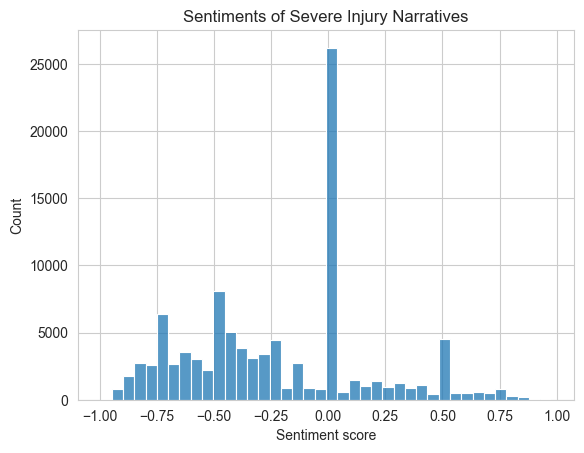

In [55]:
# Plotting sentiment scores
sns.histplot(df, x='sentiment', bins=40)
plt.xlabel('Sentiment score')
plt.title('Sentiments of Severe Injury Narratives')
plt.show()

### Interpretation

Most narratives are neutral (though more of the narratives were classfied as negative than positive), with extreme sentiment being driven by word choice, not true tone. While sentiment likely is not a strong predictive feature, it is still notable that the majority of these narratives are relatively objective (or at least neutral) in word choice.

--- 

## Final Conclusions

## Conclusions

After experimenting with multiple models using both categorical- and text-based variables, we found that our text-based SVC model performed the best overall. In fact, all of the text-based models performed surprisingly well, though the KNN model saw the largest drop in performance. For future use we would recommend the categorical SVC as it doesn't require the same intensity of preprocessing as its text counterpart while still returning comparable scores; however, consistently high scores across all models makes any of them suitable for a variety of applications. In particular, the high precision we saw would be important for any sort of auditing application.

### Applications
This work could be applied in order to:
- Identify or audit underreported hospitalizations  
- Inform targeted workplace safety interventions by extracting the most significant drivers of injury
- Extend predictions to underreporting states. 

### Future Work
Future directions for this work may include:
- Identifying key risk factors for injury
- Combining structured + text features and exploring the impact on performance
- Improving recall through model tuning, and tuning text-based models to further improve performance.